In [82]:
import pandas as pd
import matplotlib.pyplot as plt
import gspread
from gspread_dataframe import set_with_dataframe
from google.oauth2 import service_account
from google import genai



In [65]:
sa = gspread.service_account(filename="cosmic-envoy-489004-f0-28b6c08ab6d4.json")
sheet = sa.open("inventory_dataset")
work_sheet = sheet.worksheet("Sheet1")
df = pd.DataFrame(work_sheet.get_all_records())
df.head()
# df = pd.read_csv('inventory_dataset.csv')
# df

,product,category,stock,weekly_sales,cost,price,profit
0,Wine A,Red,20,12,8,15,7
1,Wine B,White,60,4,5,12,7
2,Wine C,Red,15,10,7,12,5
3,Wine D,Sparkling,80,3,10,20,10
4,Wine E,White,10,9,6,13,7


In [25]:
def inventory_decision(row):
    if row['stock'] < row['weekly_sales'] * 2:
        return "REORDER"
    elif row['weekly_sales'] < 5 and row['stock'] > 50:
        return "DISCONTINUE"
    else: 
        return "HOLD"

In [68]:
df['decision'] = df.apply(inventory_decision, axis=1)

In [69]:
df['profit'] = df['price'] - df['cost']
df['profit_margin_%'] = (df['profit']/df['price']) * 100
set_with_dataframe(work_sheet, df)
df

,product,category,stock,weekly_sales,cost,price,profit,profit_margin_%,decision
0,Wine A,Red,20,12,8,15,7,46.666667,REORDER
1,Wine B,White,60,4,5,12,7,58.333333,DISCONTINUE
2,Wine C,Red,15,10,7,12,5,41.666667,REORDER
3,Wine D,Sparkling,80,3,10,20,10,50.000000,DISCONTINUE
4,Wine E,White,10,9,6,13,7,53.846154,REORDER


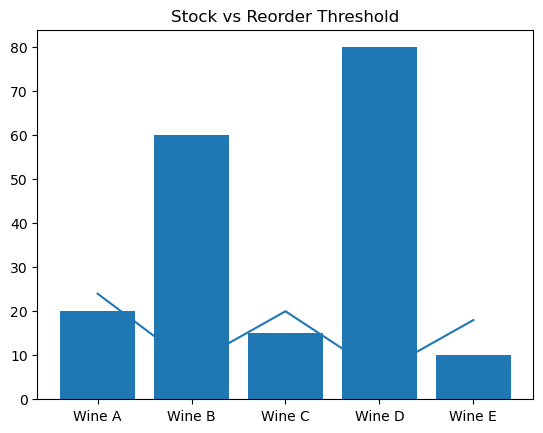

In [28]:
df['reorder_threshold'] = df['weekly_sales'] * 2
plt.figure()
plt.bar(df['product'], df['stock'])
plt.plot(df['product'], df['reorder_threshold'])
plt.title("Stock vs Reorder Threshold")
plt.show()

In [88]:
path_to_json = r"organic-victory-188601-fed00f0ba73c.json"
credentials = service_account.Credentials.from_service_account_file(
    path_to_json,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

client = genai.Client(
    vertexai=True,
    project="organic-victory-188601",
    location="us-central1",
    credentials=credentials
)

response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents="What strategy I should consider with this dataset" + str(df)
)
print(response.text)

This dataset provides a clear picture of product performance and pre-computed decisions. The core strategy should revolve around optimizing inventory, maximizing profit, and leveraging the insights from the `decision` column.

Here's a breakdown of strategies to consider:

## I. Immediate Action Based on `decision` Column

The `decision` column is the most direct guide for immediate actions.

1.  **For Products Marked `REORDER` (e.g., Wine A, C, E):**
    *   **Strategy:** Prioritize immediate replenishment to avoid stockouts and missed sales opportunities. These are high-performing, profitable items that are selling well.
    *   **Actions:**
        *   **Review Reorder Quantity:** Based on `weekly_sales`, `stock`, and supplier lead times, calculate the optimal reorder quantity to meet demand for the next few weeks/months without overstocking.
        *   **Monitor Sales Trends:** Keep a close eye on their `weekly_sales` to catch any changes in demand.
        *   **Negotiate Supplie